# Chapter 10: Clustering Techniques

Reproduksi dan pembahasan buku John Sukup, *scikit-learn Cookbook*, Third Edition (Packt, 2025). Kode diadaptasi dari [repo penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_10) beserta exercise solutions. Adaptasi metodologi dijelaskan pada bagian terkait. Dataset sintetis/bawaan dan output di bawah dipakai untuk memahami workflow pembelajaran mesin.

## Daftar Isi

- [Introduction to Clustering](#introduction-to-clustering)
- [K-Means Clustering](#k-means-clustering)
- [Hierarchical Clustering](#hierarchical-clustering)
- [Density-Based Clustering with DBSCAN](#density-based-clustering-with-dbscan)
- [Cluster Evaluation Metrics](#cluster-evaluation-metrics)
- [Choosing the Right Clustering Algorithm](#choosing-the-right-clustering-algorithm)
- [Advanced Clustering Techniques](#advanced-clustering-techniques)
- [Practical Exercises with Clustering Models](#practical-exercises-with-clustering-models)
- [Pemeriksaan Hasil](#pemeriksaan-hasil)
- [Ringkasan Bab](#ringkasan-bab)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
np.random.seed(2024)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
plt.rcParams.update({'figure.dpi': 100, 'savefig.bbox': 'tight'})
chapter_results = {}

## Introduction to Clustering

Clustering mengelompokkan sampel tanpa target training berdasarkan kemiripan fitur. Label cluster adalah nomor kelompok dan tidak memiliki arti kelas bawaan. Segmentasi pelanggan atau kelompok dokumen memerlukan interpretasi domain setelah pengelompokan. Scaling penting bagi algoritma berbasis jarak, tetapi standar skala yang dipilih juga mengubah arti kemiripan.

Contoh awal membuat 300 titik dari empat Gaussian blobs dan menerapkan StandardScaler. Karena tujuannya eksplorasi unsupervised, scaling seluruh data diperbolehkan di bagian ini; hasilnya bukan evaluasi classifier pada holdout.

In [2]:
# Load the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Create the dataset
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=2024)
X = StandardScaler().fit_transform(X)

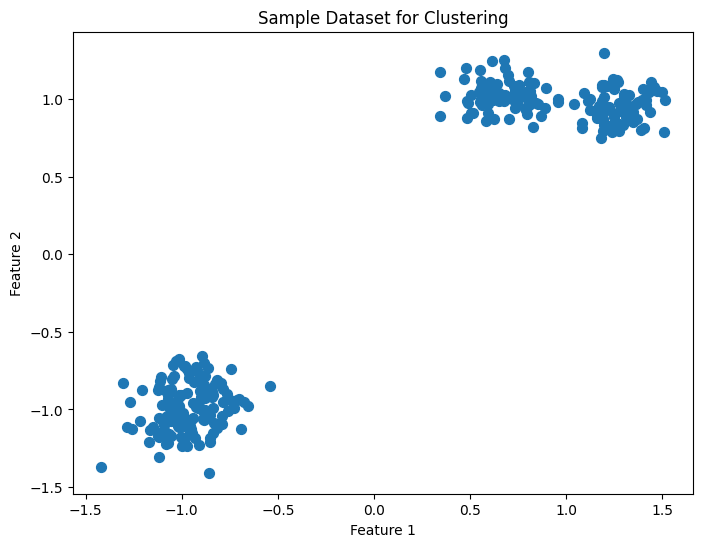

In [3]:
# Visualize the raw data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Sample Dataset for Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## K-Means Clustering

KMeans meminimalkan within-cluster sum of squares $\sum_i\|x_i-\mu_{c_i}\|^2$. Iterasi bergantian menetapkan cluster terdekat dan memperbarui centroid. Initialization k-means++ membantu memilih centroid awal; beberapa restart mengurangi ketergantungan solusi lokal. Di sini n_init=10 ditetapkan secara eksplisit.

K perlu dipilih lebih dahulu. Elbow mencari titik saat tambahan K hanya sedikit mengurangi inertia; elbow dapat ambigu dan bukan bukti jumlah kelompok yang benar. Inertia turun ketika K bertambah, sehingga nilai minimum saja selalu mendorong terlalu banyak cluster. KMeans cocok untuk kelompok relatif bulat dengan skala serupa, sensitif terhadap outlier, dan sulit mengikuti moons/circles.

In [4]:
# Load the libraries
from sklearn.cluster import KMeans
# Reuse the dataset from the previous section
# Dataset already loaded and scaled as X

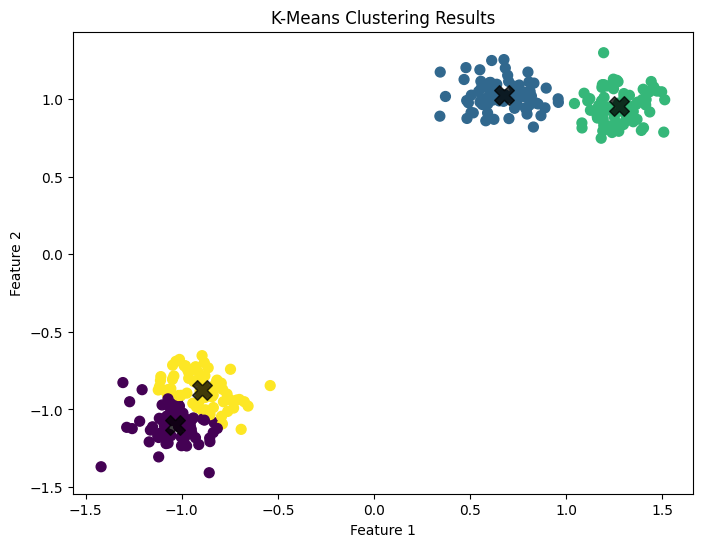

In [5]:
# Apply K-Means clustering
kmeans = KMeans(n_init=10, n_clusters=4, random_state=2024)
y_kmeans = kmeans.fit_predict(X)

# Plot the clustered data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.75, marker='X')
plt.title("K-Means Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

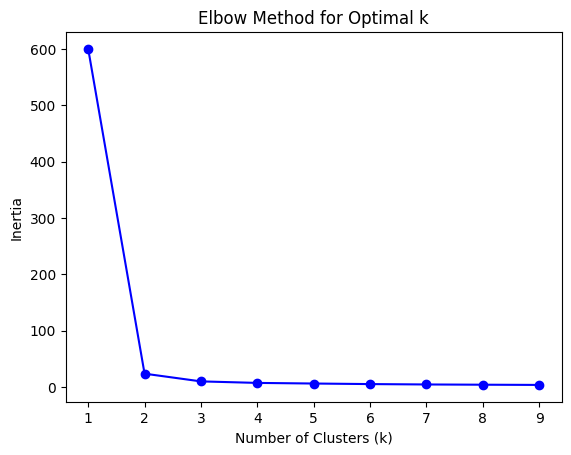

In [6]:
# Calculate and plot clustering inertia
inertia = []
k_values = range(1, 10)
for k in k_values:
    km = KMeans(n_init=10, n_clusters=k, random_state=2024)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(k_values, inertia, 'bo-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

## Hierarchical Clustering

Agglomerative clustering mulai dari satu cluster per sampel lalu menggabungkan pasangan. Linkage single memakai jarak minimum, complete maksimum, average rata-rata, sedangkan Ward meminimalkan kenaikan varians dan membutuhkan jarak Euclidean. Dendrogram menampilkan urutan serta tinggi penggabungan; tinggi bukan jumlah sampel.

Memotong dendrogram menentukan jumlah kelompok atau distance threshold. Seluruh 300 daun ditampilkan sehingga label rapat; struktur penggabungan adalah fokus. Metode ini berguna untuk struktur bertingkat tetapi dapat mahal pada data besar dan umumnya tidak menyediakan predict untuk sampel baru.

In [7]:
# Load the libraries
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Reuse the dataset from the earlier section
# Dataset already loaded and scaled as X

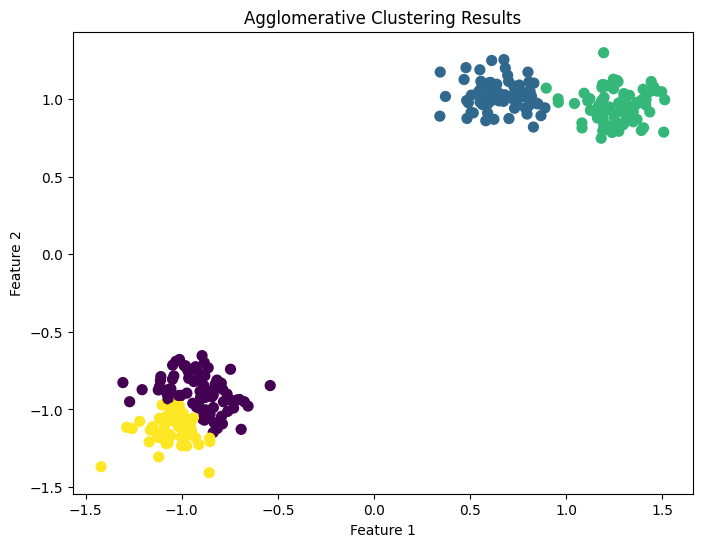

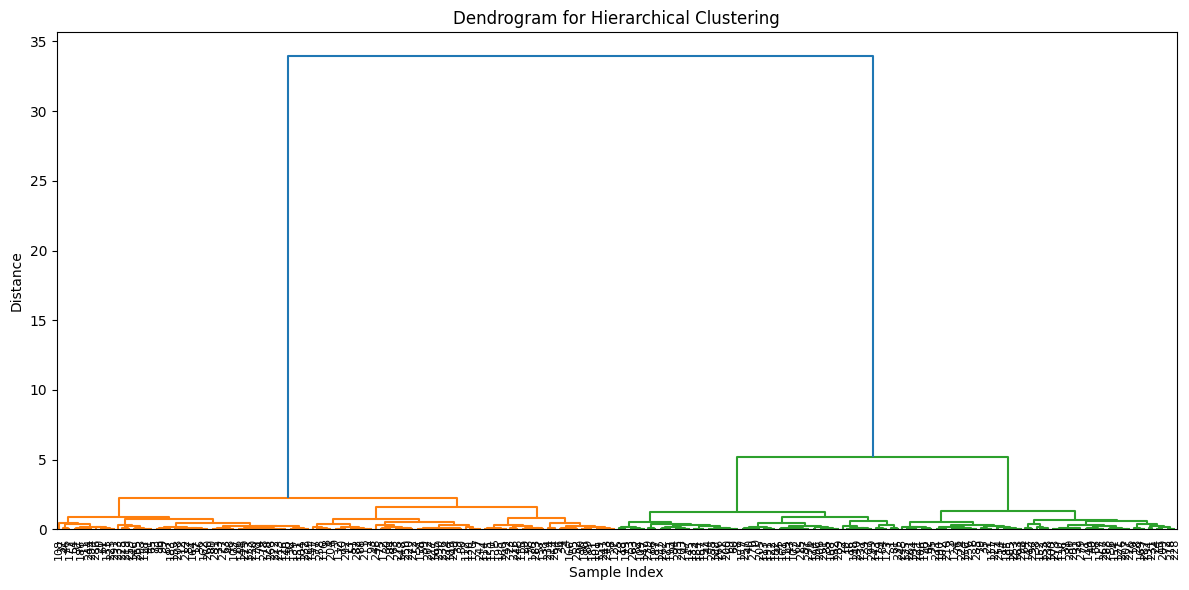

In [8]:
# Apply agglomerative clustering
agg = AgglomerativeClustering(n_clusters=4)
y_agg = agg.fit_predict(X)

# Plot the clustered data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_agg, cmap='viridis', s=50)
plt.title("Agglomerative Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Generate the dendrogram using SciPy
linked = linkage(X, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Density-Based Clustering with DBSCAN

DBSCAN menghubungkan daerah padat melalui core points. eps menentukan radius; min_samples mencakup titik itu sendiri. Border point dekat core tetapi belum memenuhi jumlah tetangga; noise berlabel -1. DBSCAN tidak meminta K dan dapat menangkap bentuk nonconvex, tetapi sensitif pada skala dan kelompok dengan density berbeda.

Contoh memakai moons tanpa scaling, lalu latihan memakai moons yang distandardisasi; eps tidak dapat dibandingkan langsung antarrepresentasi. K-distance memberi petunjuk radius, bukan pilihan otomatis yang pasti. Pemanggilan kneighbors(X) memasukkan titik sendiri pada posisi jarak nol, konsisten dengan definisi min_samples.

In [9]:
# Load the libraries
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Create a new one with noise
X, _ = make_moons(n_samples=300, noise=0.1, random_state=2024)

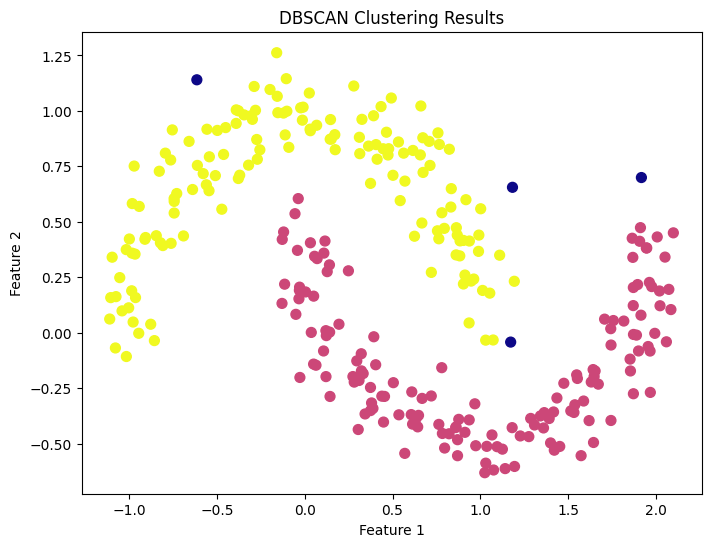

In [10]:
# Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_db = dbscan.fit_predict(X)

# Plot the DBSCAN results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_db, cmap='plasma', s=50)
plt.title("DBSCAN Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

chapter_results['dbscan_moons_noise'] = int(np.sum(y_db == -1))
chapter_results['dbscan_moons_clusters'] = len(set(y_db) - {-1})

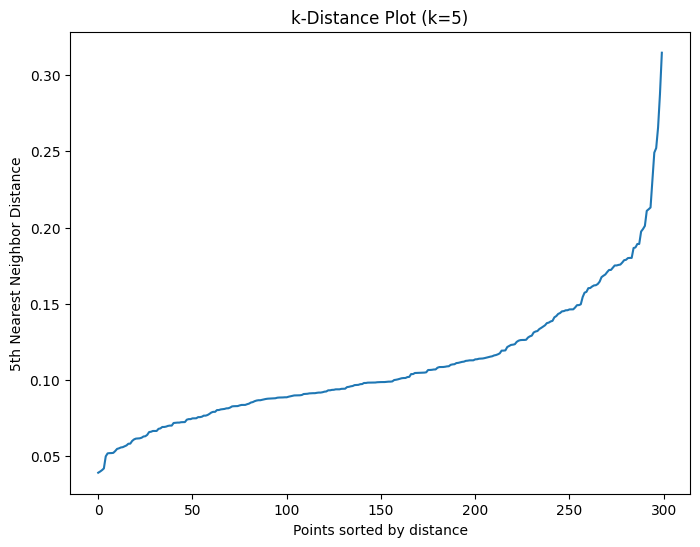

In [11]:
# Load libraries
from sklearn.neighbors import NearestNeighbors

# Generate Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:, 4])

# Plot k-distance
plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.title("k-Distance Plot (k=5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.show()

## Cluster Evaluation Metrics

Silhouette $s=(b-a)/\max(a,b)$ membandingkan jarak rata-rata dalam cluster (a) dengan cluster lain terdekat (b). Nilai lebih tinggi umumnya menunjukkan kelompok lebih terpisah dan memerlukan setidaknya dua cluster. Davies–Bouldin lebih rendah lebih baik karena merangkum rasio sebaran dalam kelompok terhadap jarak centroid.

Adjusted Rand Index (ARI) membandingkan pasangan anggota cluster dengan label referensi dan mengoreksi kesesuaian acak; ARI invariant terhadap pertukaran nomor cluster. Label sintetis dipakai hanya untuk evaluasi, tidak untuk fit KMeans. Untuk DBSCAN, noise perlu dilaporkan terpisah dan aturan memasukkan/mengeluarkannya dari metrik harus jelas.

In [12]:
# Load the libraries
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate a labeled dataset for evaluation
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=2024)

# Fit KMeans for use with evaluation metrics
kmeans = KMeans(n_init=10, n_clusters=4, random_state=2024)
y_kmeans = kmeans.fit_predict(X)

In [13]:
# Calculate the silhouette score
sil_score = silhouette_score(X, y_kmeans)
print(f"Silhouette Score: {sil_score:.3f}")

# Calculate the Davies-Bouldin index
db_index = davies_bouldin_score(X, y_kmeans)
print(f"Davies-Bouldin Index: {db_index:.3f}")

# (Optional) Calculate adjusted Rand index if ground truth is known
ari = adjusted_rand_score(y_true, y_kmeans)
print(f"Adjusted Rand Index: {ari:.3f}")

chapter_results.update(blobs_silhouette=float(sil_score), blobs_davies_bouldin=float(db_index), blobs_ari=float(ari))

Silhouette Score: 0.534
Davies-Bouldin Index: 0.702
Adjusted Rand Index: 0.814


## Choosing the Right Clustering Algorithm

Blobs, moons, dan circles menggambarkan geometri berbeda. Pilihan mempertimbangkan bentuk, density, ukuran data, dimensi, noise, interpretabilitas, dan kebutuhan predict titik baru. Silhouette yang tinggi tidak selalu sesuai tujuan bisnis. Stabilitas terhadap seed, scaling, serta subsampling membantu menilai apakah segmentasi dapat diandalkan.

KMeans cepat untuk centroid; DBSCAN untuk density/nonconvex dan noise; hierarchical untuk hubungan bertingkat. Jarak pada dimensi tinggi dapat kehilangan daya pembeda, sehingga seleksi fitur atau reduksi dimensi perlu dipertimbangkan tanpa menjadikan plot 2D sebagai bukti akhir.

In [14]:
# Load the libraries
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.preprocessing import StandardScaler

# Create and scale different datasets
X_blobs, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=2024)
X_moons, _ = make_moons(n_samples=300, noise=0.1, random_state=2024)
X_circles, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=2024)

X_blobs = StandardScaler().fit_transform(X_blobs)
X_moons = StandardScaler().fit_transform(X_moons)
X_circles = StandardScaler().fit_transform(X_circles)

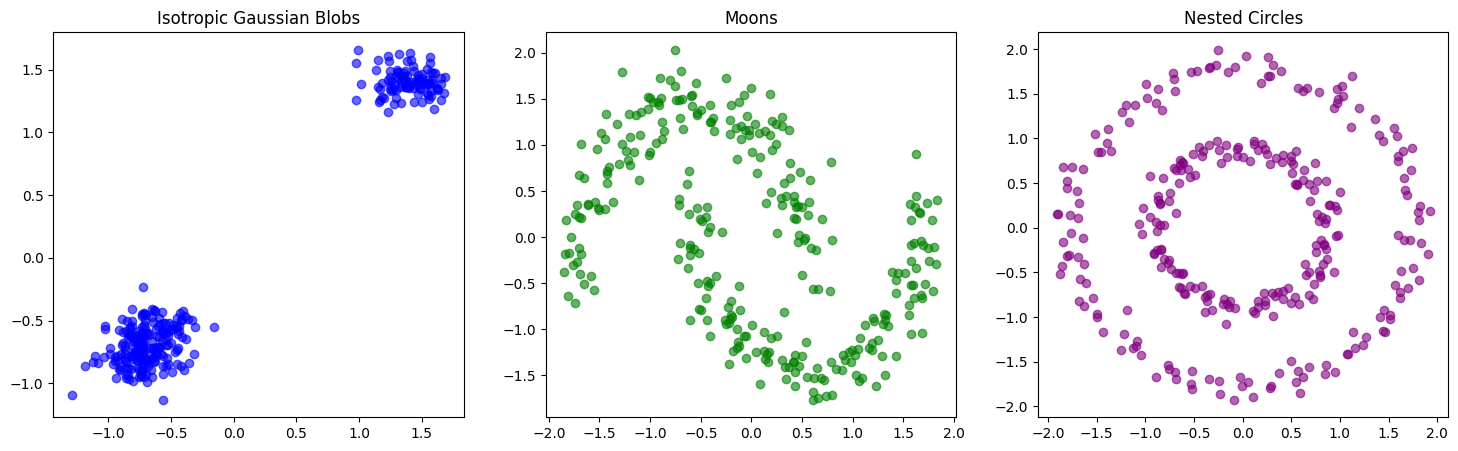

In [15]:
# Visualize the datasets
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c='blue', alpha=0.6)
axs[0].set_title("Isotropic Gaussian Blobs")
axs[1].scatter(X_moons[:, 0], X_moons[:, 1], c='green', alpha=0.6)
axs[1].set_title("Moons")
axs[2].scatter(X_circles[:, 0], X_circles[:, 1], c='purple', alpha=0.6)
axs[2].set_title("Nested Circles")
plt.show()

## Advanced Clustering Techniques

Spectral clustering membuat graf similarity lalu menggunakan eigenvector Laplacian sebelum pengelompokan. Graph connectivity dan pemilihan affinity memengaruhi hasil; jumlah cluster tetap perlu ditentukan. Gaussian Mixture Model (GMM) memakai distribusi Gaussian campuran dan EM untuk mengestimasi mean, covariance, serta bobot. `predict_proba` memberi soft assignment, bukan probabilitas kelas berlabel yang telah dikalibrasi.

GMM menangkap kelompok elips tetapi satu Gaussian per cluster tidak dapat mengikuti lengkungan moons dengan baik. BIC/AIC membantu memilih jumlah komponen dengan penalti kompleksitas, tanpa menjamin jumlah kategori dunia nyata. Kedua model dibandingkan pada representasi dan data yang sama.

In [16]:
# Load the libraries
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture
# Create datasets with complex structure
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X, _ = make_moons(n_samples=300, noise=0.05, random_state=2024)
X = StandardScaler().fit_transform(X)

T:\data projek kuliah\scikit-learn-cookbook\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


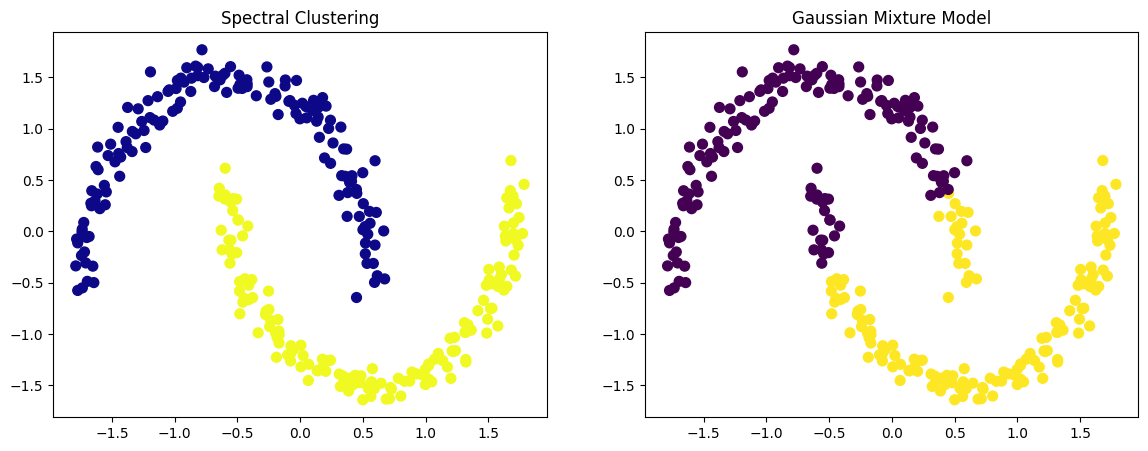

In [17]:
# Apply Spectral Clustering
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=2024)
y_spectral = spectral.fit_predict(X)

# Apply Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, random_state=2024)
y_gmm = gmm.fit_predict(X)

# Visualize both clustering results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X[:, 0], X[:, 1], c=y_spectral, cmap='plasma', s=50)
ax1.set_title("Spectral Clustering")

ax2.scatter(X[:, 0], X[:, 1], c=y_gmm, cmap='viridis', s=50)
ax2.set_title("Gaussian Mixture Model")

plt.show()

np.testing.assert_allclose(gmm.predict_proba(X).sum(axis=1), 1)
chapter_results['gmm_moons_silhouette'] = silhouette_score(X, y_gmm)
chapter_results['spectral_moons_silhouette'] = silhouette_score(X, y_spectral)

Graf nearest-neighbor pada contoh moons ini tidak sepenuhnya terhubung, sehingga scikit-learn mengeluarkan peringatan spectral embedding. Output tetap ditampilkan sebagai reproduksi contoh, tetapi hasilnya perlu diuji terhadap pilihan affinity dan jumlah tetangga sebelum digunakan sebagai segmentasi. Peringatan tersebut dipertahankan dalam output dan dicatat pada laporan validasi.

## Practical Exercises with Clustering Models

Exercise 1 menerapkan KMeans pada fitur Iris asli dan mengevaluasi silhouette/ARI terhadap spesies yang tidak dipakai saat fit. PCA hanya memproyeksikan hasil untuk visualisasi. Exercise 2 membandingkan KMeans dan DBSCAN pada moons dengan scaling yang sama; noise dilaporkan. Exercise 3 menstandardisasi Wine, memproyeksikan dua PCA, lalu fit GMM tiga komponen. Varians PCA yang hilang dan ARI pada ruang tersebut membatasi interpretasi; cluster bukan otomatis label varietas Wine.

Silhouette Score: 0.553
Adjusted Rand Index: 0.730


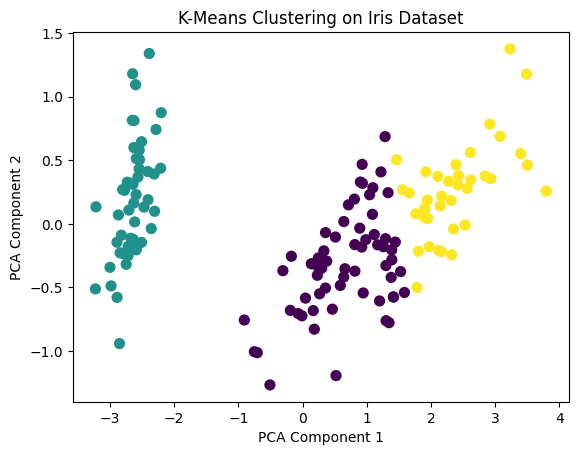

In [18]:
# Load libraries
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

# Load the Dataset
iris = load_iris()
X = iris.data
y_true = iris.target

# Create and Train the KMeans Model
kmeans = KMeans(n_init=10, n_clusters=3, random_state=2024)
y_kmeans = kmeans.fit_predict(X)

# Evaluate the Clustering
sil_score = silhouette_score(X, y_kmeans)
ari = adjusted_rand_score(y_true, y_kmeans)

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Adjusted Rand Index: {ari:.3f}")

# Visualize the Cluster Assignments (PCA Projection)
from sklearn.decomposition import PCA

X_pca = PCA(n_components=2).fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', s=50)
plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

chapter_results['iris_ari'] = adjusted_rand_score(y_true, y_kmeans)
chapter_results['iris_silhouette'] = silhouette_score(X, y_kmeans)

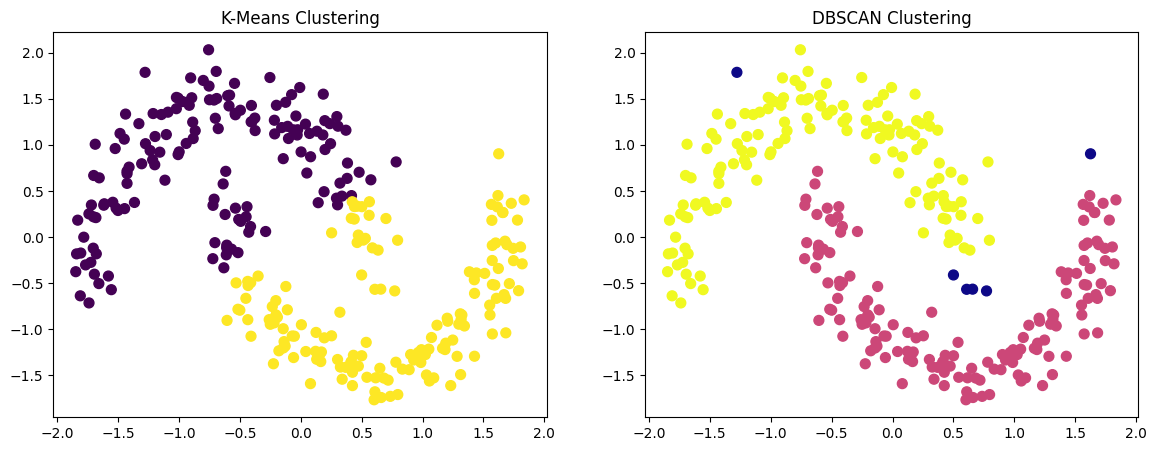

In [19]:
# Load libraries
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
import matplotlib.pyplot as plt

# Create and Scale the Dataset
X, _ = make_moons(n_samples=300, noise=0.1, random_state=2024)
X = StandardScaler().fit_transform(X)

# Apply KMeans and DBSCAN
kmeans = KMeans(n_init=10, n_clusters=2, random_state=2024)
y_kmeans = kmeans.fit_predict(X)

dbscan = DBSCAN(eps=0.3, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

# Visualize the Clustering Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=50)
ax1.set_title("K-Means Clustering")

ax2.scatter(X[:, 0], X[:, 1], c=y_dbscan, cmap='plasma', s=50)
ax2.set_title("DBSCAN Clustering")

plt.show()

chapter_results['exercise_moons_noise'] = int(np.sum(y_dbscan == -1))

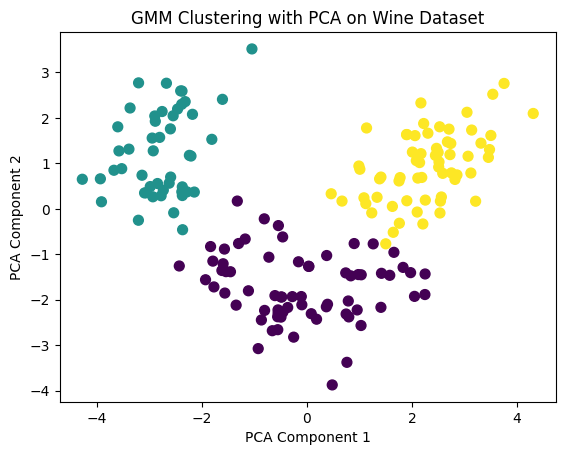

In [20]:
# Load libraries
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Load and Preprocess the Dataset
data = load_wine()
X = StandardScaler().fit_transform(data.data)

# Apply PCA for Dimensionality Reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Fit Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=2024)
y_gmm = gmm.fit_predict(X_pca)

# Visualize the Clustered Output
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_gmm, cmap='viridis', s=50)
plt.title("GMM Clustering with PCA on Wine Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

chapter_results['wine_pca_variance'] = float(pca.explained_variance_ratio_.sum())
chapter_results['wine_gmm_ari'] = adjusted_rand_score(data.target, y_gmm)

## Pemeriksaan Hasil

Assertion di bawah memeriksa konsistensi hasil dan keluaran, bukan membuktikan seluruh asumsi statistik.

In [21]:
assert chapter_results
assert -1 <= chapter_results['blobs_silhouette'] <= 1
assert -1 <= chapter_results['iris_ari'] <= 1
assert 0 < chapter_results['wine_pca_variance'] <= 1
print(json.dumps(chapter_results, indent=2))

{
  "dbscan_moons_noise": 4,
  "dbscan_moons_clusters": 2,
  "blobs_silhouette": 0.5342781913950685,
  "blobs_davies_bouldin": 0.7017329696200063,
  "blobs_ari": 0.8138286761557577,
  "gmm_moons_silhouette": 0.4954970008061373,
  "spectral_moons_silhouette": 0.38672542030223445,
  "iris_ari": 0.7302382722834697,
  "iris_silhouette": 0.5528190123564095,
  "exercise_moons_noise": 6,
  "wine_pca_variance": 0.5540633835693526,
  "wine_gmm_ari": 0.9135013666962891
}


## Ringkasan Bab

KMeans pada blobs menghasilkan silhouette **0.534**, Davies–Bouldin **0.702**, dan ARI **0.814**. Walaupun data dibangkitkan dengan empat pusat, sebagian kelompok saling dekat sehingga label tidak selalu dipulihkan sempurna. DBSCAN awal menemukan **2 cluster** dan **4 noise points** pada moons.

Iris menghasilkan ARI **0.730**; proyeksi dua PCA Wine mempertahankan **55.4%** varians dan GMM pada ruang itu menghasilkan ARI **0.914**. Jumlah dan bentuk kelompok bergantung pada representasi, algoritma, serta parameter. Label cluster tidak memiliki makna kelas tanpa interpretasi tambahan.